# 02 - Exploratory data analysis

The questions from the project brief, answered with the named SQL queries in
`sql/03_business_queries.sql` (the dashboard runs the same queries), plus significance tests.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display
from src import config
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
from scipy import stats
from src.data_preprocessing import run_named_query
feats = pd.read_csv(config.FEATURES_CSV)

## Churn by segment

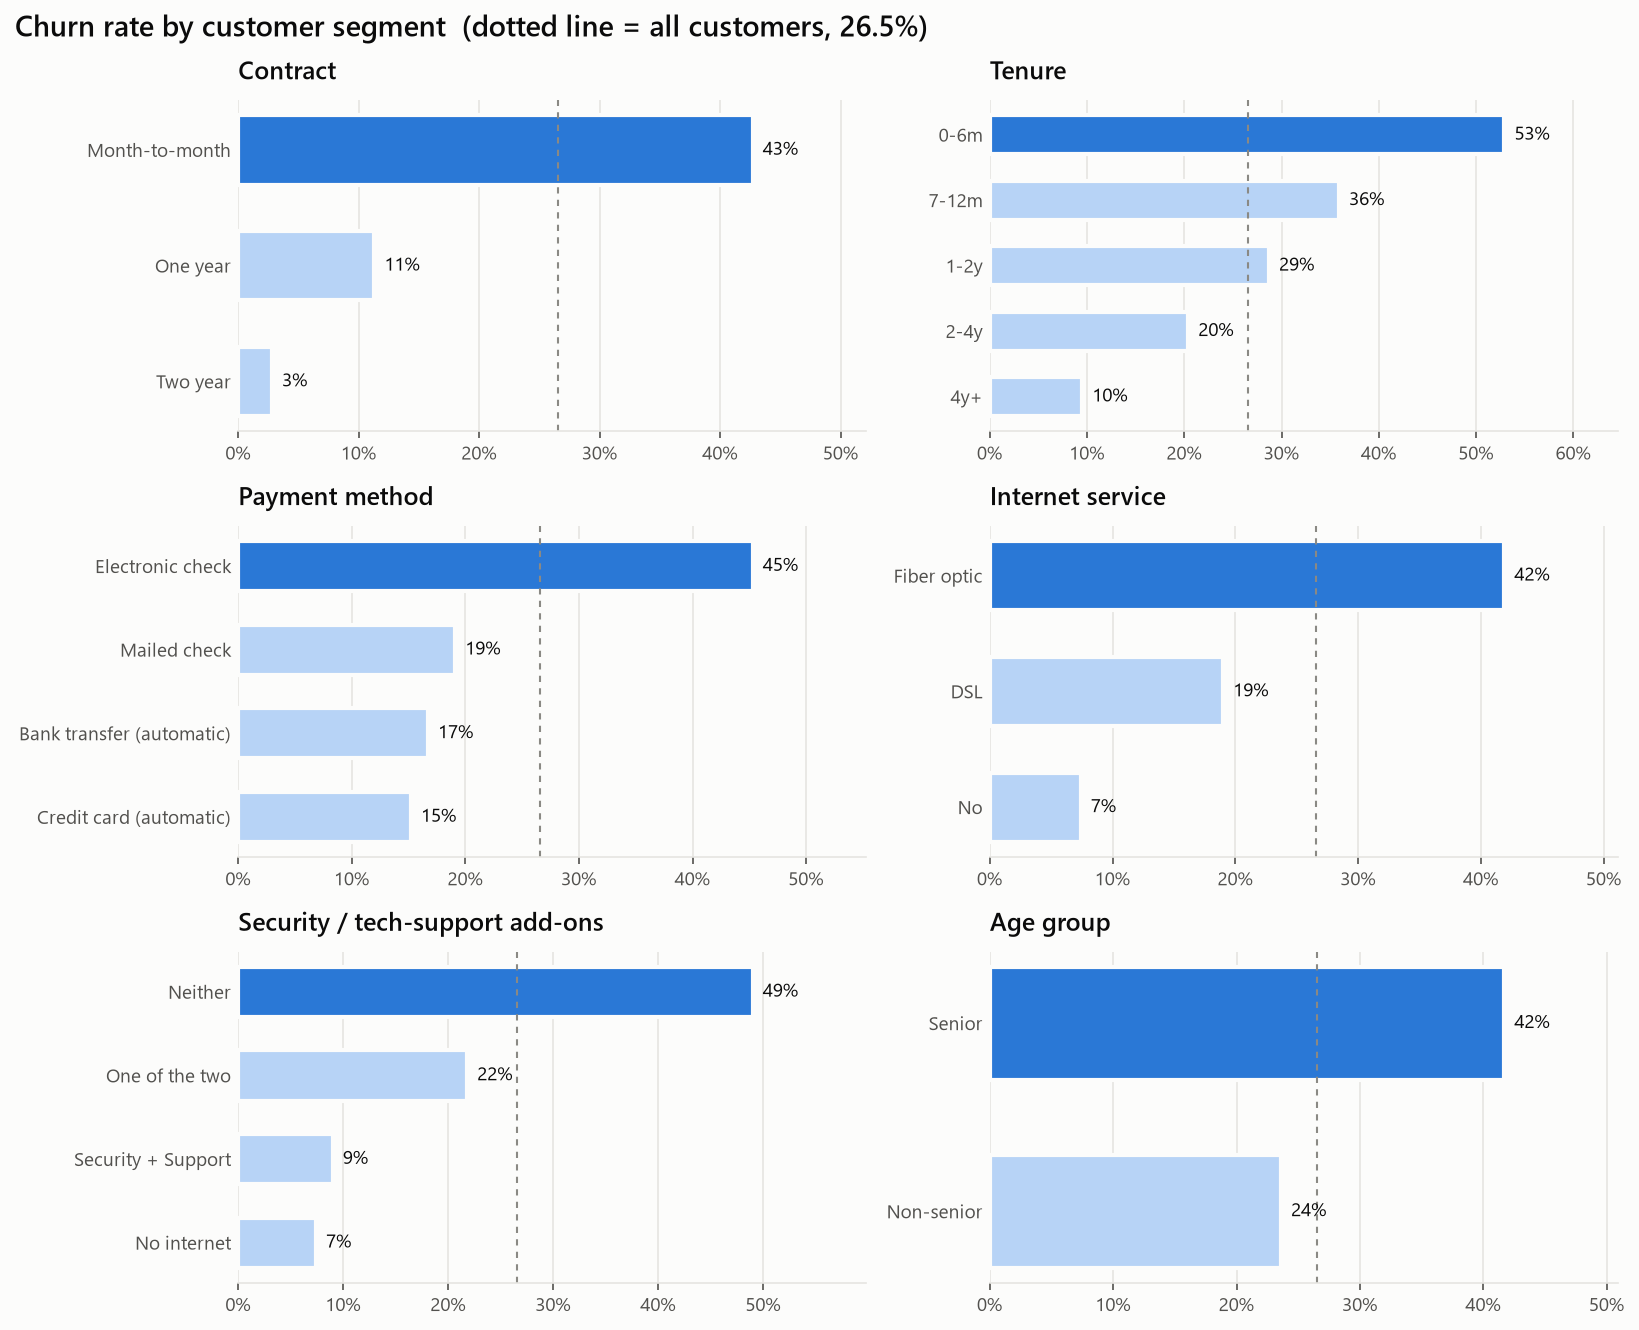

In [2]:
display(Image(str(config.FIGURES_DIR / "eda_churn_by_segment.png")))

In [3]:
for q in ["churn_by_contract", "churn_by_tenure_bucket", "churn_by_payment_method",
          "churn_by_internet_service", "churn_by_protection", "churn_by_senior"]:
    print(f"--- {q}"); print(run_named_query(q).to_string(index=False)); print()

--- churn_by_contract
       segment  customers  churned  churn_rate_pct  annual_revenue_lost
Month-to-month       3875     1655            42.7            1450165.0
      One year       1473      166            11.3             169421.0
      Two year       1695       48             2.8              49984.0

--- churn_by_tenure_bucket
segment  customers  churned  churn_rate_pct  avg_monthly_charges
   0-6m       1481      784            52.9                54.74
  7-12m        705      253            35.9                58.95
   1-2y       1024      294            28.7                61.36
   2-4y       1594      325            20.4                65.93
    4y+       2239      213             9.5                73.95

--- churn_by_payment_method
                  segment  customers  churned  churn_rate_pct
         Electronic check       2365     1071            45.3
             Mailed check       1612      308            19.1
Bank transfer (automatic)       1544      258            

## Does tenure affect churn? When do customers leave?

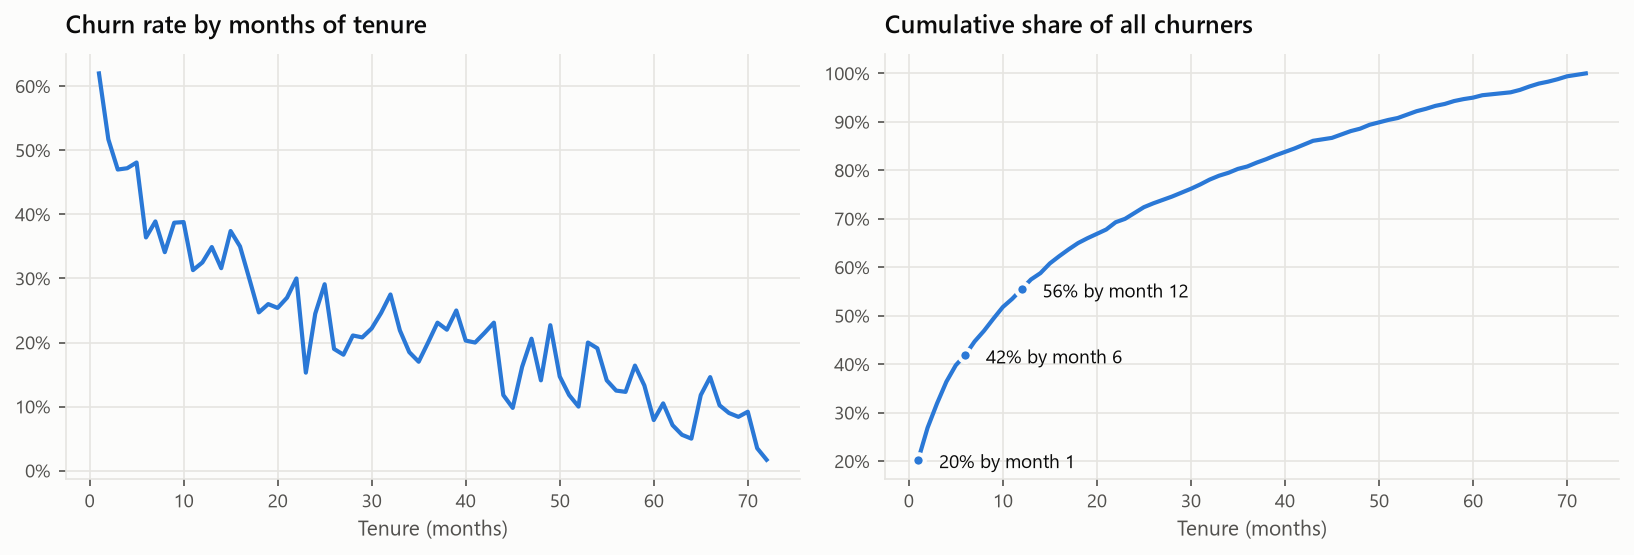

,tenure,customers,churned,churn_rate_pct,cumulative_share_of_churners_pct
1,1,613,380,62.0,20.3
3,3,200,94,47.0,31.9
6,6,110,40,36.4,41.9
12,12,117,38,32.5,55.5
24,24,94,23,24.5,71.2


In [4]:
display(Image(str(config.FIGURES_DIR / "eda_tenure_curve.png")))
tm = run_named_query("churn_by_tenure_month")
tm[tm["tenure"].isin([1, 3, 6, 12, 24])]

## Does monthly cost affect churn?

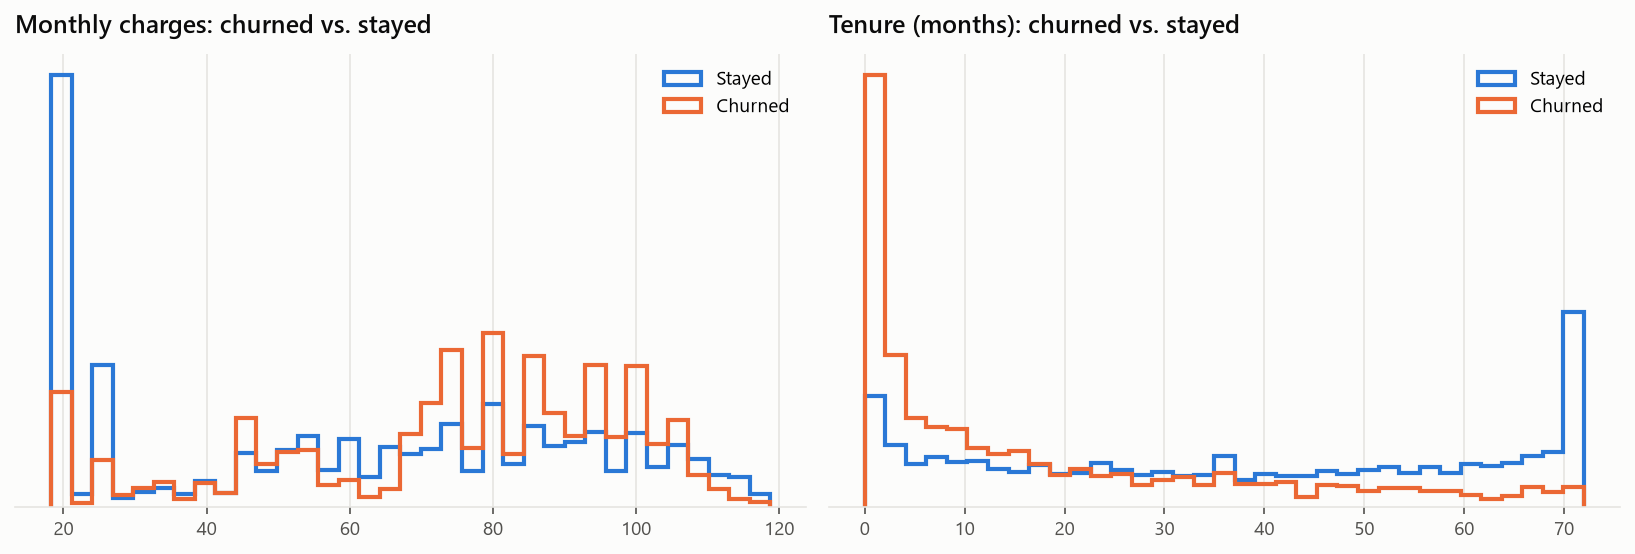

,monthly_charges,tenure,total_charges
churn,,,
0,64.425,38.0,1679.525
1,79.650,10.0,703.550


In [5]:
display(Image(str(config.FIGURES_DIR / "eda_distributions.png")))
feats.groupby("churn")[["monthly_charges", "tenure", "total_charges"]].median()

## Are the differences real? Significance tests

In [6]:
def cramers_v(table):
    chi2 = stats.chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))

rows = []
for col in ["contract", "payment_method", "internet_service", "tech_support", "online_security",
            "paperless_billing", "senior_citizen", "partner", "dependents", "gender", "phone_service"]:
    table = pd.crosstab(feats[col], feats["churn"])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    rows.append({"feature": col, "test": "chi-square", "p_value": p, "effect_size": cramers_v(table),
                 "effect": "Cramer's V"})
for col in ["tenure", "monthly_charges", "total_charges"]:
    a, b = feats.loc[feats.churn == 1, col], feats.loc[feats.churn == 0, col]
    u, p = stats.mannwhitneyu(a, b)
    rows.append({"feature": col, "test": "Mann-Whitney U", "p_value": p,
                 "effect_size": abs(1 - 2 * u / (len(a) * len(b))), "effect": "rank-biserial r"})
tests = pd.DataFrame(rows).sort_values("effect_size", ascending=False)
tests["significant (p<0.001)"] = tests["p_value"] < 0.001
tests.round(4)

,feature,test,p_value,effect_size,effect,significant (p<0.001)
11,tenure,Mann-Whitney U,0.0000,0.4797,rank-biserial r,True
0,contract,chi-square,0.0000,0.4101,Cramer's V,True
2,internet_service,chi-square,0.0000,0.3225,Cramer's V,True
1,payment_method,chi-square,0.0000,0.3034,Cramer's V,True
13,total_charges,Mann-Whitney U,0.0000,0.3007,rank-biserial r,True
12,monthly_charges,Mann-Whitney U,0.0000,0.2416,rank-biserial r,True
5,paperless_billing,chi-square,0.0000,0.1915,Cramer's V,True
4,online_security,chi-square,0.0000,0.1709,Cramer's V,True
3,tech_support,chi-square,0.0000,0.1643,Cramer's V,True
8,dependents,chi-square,0.0000,0.1639,Cramer's V,True


Everything except **gender** (p = 0.49) and **phone service** (p = 0.34) is significant at
p < 0.001. Effect sizes rank the drivers: tenure (r = 0.48) and contract type (V = 0.41) are
strongest, followed by internet service and payment method (V ~ 0.30-0.32); paperless billing and
the security/support add-ons have moderate effects (V ~ 0.16-0.19). Gender has no effect at all -
a useful check that the model should not lean on it (and SHAP confirms it doesn't).

## Correlation between numeric features

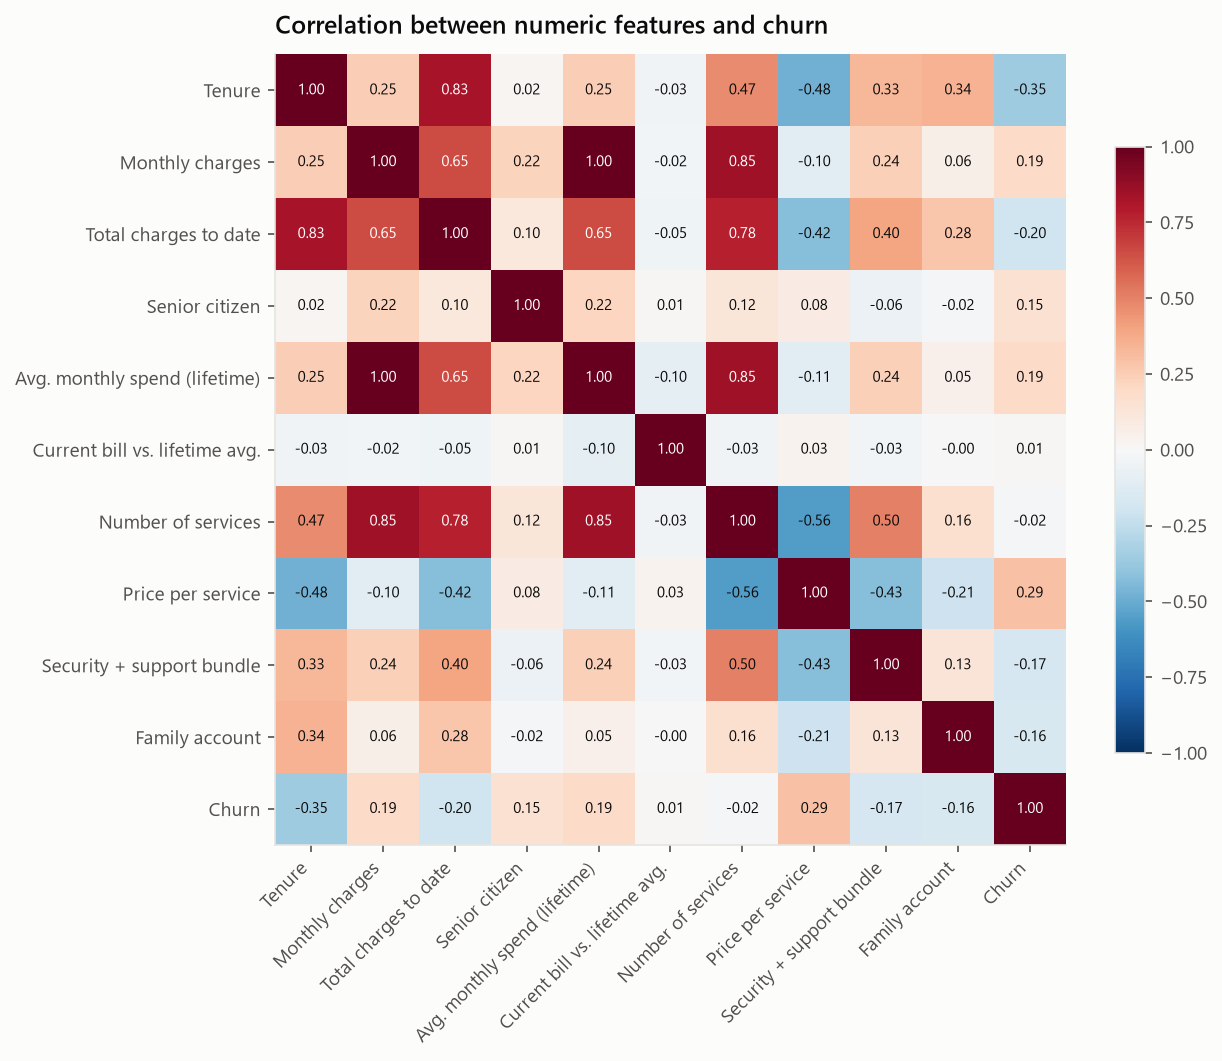

In [7]:
display(Image(str(config.FIGURES_DIR / "eda_correlation.png")))

`total_charges` is strongly correlated with `tenure` (0.83) and `avg_monthly_spend` is almost
identical to `monthly_charges`. Fine for trees and regularised regression, but it means
importance is *shared* between these columns - one reason SHAP explanations are summed per
business feature rather than read column by column.

## Key findings

1. **Contract is the #1 driver.** Month-to-month customers churn at 42.7% vs. 2.8% on two-year contracts.
2. **Churn is front-loaded.** 20% of all churners leave in month 1 and ~40% within 5 months: onboarding is where retention is won.
3. **Fiber customers churn at 41.9%** despite (or because of) paying the most - a price/value problem, not a product-adoption one.
4. **Security + tech support matter**: 49% churn with neither, 9% with both.
5. **Electronic-check payers churn at 45%**, 3x the automatic-payment rate.
6. **Month-to-month fiber** is the single riskiest cell (54.6%).